In [1]:
import matplotlib.pyplot as plt
import torch

from rectified_flow.datasets.toy_gmm import TwoPointGMM

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

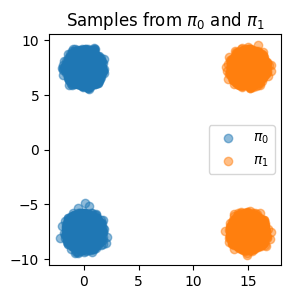

In [2]:
n_samples = 50000
pi_0 = TwoPointGMM(x=0.0, y=7.5, std=0.5, device=device)
pi_1 = TwoPointGMM(x=15.0, y=7.5, std=0.5, device=device)

D0 = pi_0.sample([n_samples])
D1, labels = pi_1.sample_with_labels([n_samples])

plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(D0[:, 0].cpu(), D0[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(D1[:, 0].cpu(), D1[:, 1].cpu(), alpha=0.5, label=r'$\pi_1$')
plt.legend()

In [3]:
import numpy as np
from rectified_flow.utils import visualize_2d_trajectories_plotly

# 1 - rectified flow
x_0 = pi_0.sample([500])
x_0_upper = x_0.clone()
x_0_upper[:, 1] = torch.abs(x_0_upper[:, 1])
x_0_lower = x_0.clone()
x_0_lower[:, 1] = -torch.abs(x_0_lower[:, 1])

x_1_upper = pi_1.sample([500])
x_1_lower = pi_1.sample([500])

interp_upper = []
interp_lower = []

for t in np.linspace(0, 1, 100):
    x_t_uppper = (1 - t) * x_0_upper + t * x_1_upper
    x_t_lower = (1 - t) * x_0_lower + t * x_1_lower
    interp_upper.append(x_t_uppper)
    interp_lower.append(x_t_lower)

visualize_2d_trajectories_plotly(
    trajectories_dict={
        "upper": interp_upper,
        "lower": interp_lower,
    },
    D1_gt_samples=torch.cat([x_1_upper, x_1_lower], dim=0),
    num_trajectories=100,
    title="Straight Interpolation",
)